# 10 -- Benchmark Comparison
## LLM Lie Detector | Phase 6

This notebook compares the fine-tuned hallucination detector against
two baselines on the same validation set.

### Baselines
- **DeBERTa-v3-base** -- lightweight NLI classifier, zero-shot
- **Zero-shot Llama 3.2 3B** -- base model with no fine-tuning

### Goal
Demonstrate that fine-tuning provides meaningful improvement over
both a classical NLP baseline and a zero-shot LLM approach.

In [1]:
import os
os.environ["PYTHONUTF8"] = "1"

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from peft import PeftModel
from huggingface_hub import login
from dotenv import load_dotenv

load_dotenv('../.env')
login(token=os.getenv("HF_TOKEN"))

print("All imports successful.")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


All imports successful.
CUDA available: True
GPU: NVIDIA GeForce RTX 4080 Laptop GPU


In [2]:
# Recreate validation set -- use 200 samples for fair comparison
df = pd.read_csv('../data/combined_dataset.csv')

_, val_df = train_test_split(
    df,
    test_size=0.1,
    random_state=42,
    stratify=df['label']
)
val_df = val_df.reset_index(drop=True)

# Use same 200 samples as calibration notebook for consistency
sample_df = val_df.sample(200, random_state=42).reset_index(drop=True)

print(f"Benchmark sample: {len(sample_df)} samples")
print(f"Label distribution:\n{sample_df['label'].value_counts()}")

Benchmark sample: 200 samples
Label distribution:
label
1    104
0     96
Name: count, dtype: int64


In [3]:
model_id = "meta-llama/Llama-3.2-3B-Instruct"
adapter_id = "tamimmirza/llama-3.2-3b-hallucination-detector"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token

print("Loading base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    dtype=torch.bfloat16,
    device_map="auto"
)

print("Loading LoRA adapter...")
finetuned_model = PeftModel.from_pretrained(base_model, adapter_id)
finetuned_model.eval()

print(f"\nFine-tuned model ready.")
print(f"VRAM: {torch.cuda.memory_allocated(0) / 1e9:.1f} GB")

Loading tokenizer...
Loading base model...


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Loading LoRA adapter...


W0512 12:39:22.693000 22592 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels



Fine-tuned model ready.
VRAM: 6.4 GB


In [4]:
def predict_finetuned(question: str, answer: str) -> int:
    """
    Our fine-tuned Llama 3.2 3B + LoRA detector.
    Returns 1 for HALLUCINATED, 0 for TRUTHFUL.
    """
    prompt = f"Question: {question}\nAnswer: {answer}\nVerdict:"
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    with torch.no_grad():
        output = finetuned_model.generate(
            **inputs,
            max_new_tokens=10,
            temperature=0.1,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

    response = tokenizer.decode(
        output[0][inputs['input_ids'].shape[-1]:],
        skip_special_tokens=True
    ).strip().upper()

    return 1 if "HALLUCINATED" in response else 0


def predict_zeroshot(question: str, answer: str) -> int:
    """
    Zero-shot Llama 3.2 3B with no fine-tuning.
    Uses the base model with a direct classification prompt.
    Returns 1 for HALLUCINATED, 0 for TRUTHFUL.
    """
    prompt = (
        f"You are a fact-checking assistant. Given a question and an answer, "
        f"determine if the answer is factually correct or hallucinated.\n\n"
        f"Question: {question}\n"
        f"Answer: {answer}\n\n"
        f"Is this answer TRUTHFUL or HALLUCINATED? Reply with one word only."
    )

    # Use the base model without the LoRA adapter
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    with torch.no_grad():
        # Temporarily use base model
        output = base_model.generate(
            **inputs,
            max_new_tokens=10,
            temperature=0.1,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

    response = tokenizer.decode(
        output[0][inputs['input_ids'].shape[-1]:],
        skip_special_tokens=True
    ).strip().upper()

    return 1 if "HALLUCINATED" in response else 0

print("Fine-tuned and zero-shot inference functions ready.")

Fine-tuned and zero-shot inference functions ready.


In [5]:
print("Loading DeBERTa-v3 NLI pipeline...")

# DeBERTa-v3 zero-shot classification
# We frame hallucination detection as NLI:
# premise = answer, hypothesis = "This is a factually correct statement"
deberta_pipeline = pipeline(
    "zero-shot-classification",
    model="cross-encoder/nli-deberta-v3-base",
    device=0  # use GPU
)

def predict_deberta(question: str, answer: str) -> int:
    """
    DeBERTa-v3 zero-shot NLI classifier.
    Frames hallucination detection as natural language inference.
    Returns 1 for HALLUCINATED, 0 for TRUTHFUL.
    """
    # Premise: the answer
    # Hypothesis: it is factually correct
    premise = f"Question: {question} Answer: {answer}"
    hypothesis = "This answer is factually correct and not hallucinated."

    result = deberta_pipeline(
        premise,
        candidate_labels=["factually correct", "hallucinated"],
    )

    # If "hallucinated" scores higher, return 1
    labels = result['labels']
    scores = result['scores']
    top_label = labels[0]

    return 1 if top_label == "hallucinated" else 0

print("DeBERTa pipeline ready.")
print(f"VRAM: {torch.cuda.memory_allocated(0) / 1e9:.1f} GB")

Loading DeBERTa-v3 NLI pipeline...


config.json: 0.00B [00:00, ?B/s]

c:\ML Projects\llm-lie-detector\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Tamim\.cache\huggingface\hub\models--cross-encoder--nli-deberta-v3-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/738M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

...

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

DeBERTa pipeline ready.
VRAM: 7.2 GB


In [6]:
print("Running benchmark comparison on 200 samples...")
print("This will take several minutes -- three models, 200 samples each.\n")

results = []

for i, row in sample_df.iterrows():
    # Fine-tuned model
    pred_ft = predict_finetuned(row['question'], row['answer'])
    
    # Zero-shot Llama
    pred_zs = predict_zeroshot(row['question'], row['answer'])
    
    # DeBERTa
    pred_db = predict_deberta(row['question'], row['answer'])
    
    results.append({
        'question':      row['question'],
        'answer':        row['answer'],
        'true_label':    row['label'],
        'pred_finetuned': pred_ft,
        'pred_zeroshot':  pred_zs,
        'pred_deberta':   pred_db,
    })
    
    if (i + 1) % 50 == 0:
        print(f"Progress: {i+1}/200 samples processed")

results_df = pd.DataFrame(results)
print("\nDone.")

Running benchmark comparison on 200 samples...
This will take several minutes -- three models, 200 samples each.



[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Progress: 50/200 samples processed
Progress: 100/200 samples processed
Progress: 150/200 samples processed
Progress: 200/200 samples processed

Done.


In [7]:
true_labels = results_df['true_label'].tolist()

# Compute metrics for all three systems
systems = {
    'Fine-tuned Llama (Ours)': results_df['pred_finetuned'].tolist(),
    'Zero-shot Llama':         results_df['pred_zeroshot'].tolist(),
    'DeBERTa-v3 (NLI)':       results_df['pred_deberta'].tolist(),
}

print("=" * 65)
print("BENCHMARK COMPARISON RESULTS (200 samples)")
print("=" * 65)
print(f"{'System':<25} {'F1':>8} {'Precision':>10} {'Recall':>8} {'Accuracy':>10}")
print("-" * 65)

benchmark_results = []
for name, preds in systems.items():
    f1       = f1_score(true_labels, preds, average='weighted')
    precision = precision_score(true_labels, preds, average='weighted')
    recall   = recall_score(true_labels, preds, average='weighted')
    accuracy = accuracy_score(true_labels, preds)
    
    print(f"{name:<25} {f1:>8.4f} {precision:>10.4f} {recall:>8.4f} {accuracy:>10.4f}")
    benchmark_results.append({
        'System': name,
        'F1': round(f1, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'Accuracy': round(accuracy, 4),
    })

print("=" * 65)

benchmark_df = pd.DataFrame(benchmark_results)
benchmark_df.to_csv('../outputs/benchmark_results.csv', index=False)
print("\nSaved to outputs/benchmark_results.csv")

BENCHMARK COMPARISON RESULTS (200 samples)
System                          F1  Precision   Recall   Accuracy
-----------------------------------------------------------------
Fine-tuned Llama (Ours)     0.9149     0.9153   0.9150     0.9150
Zero-shot Llama             0.3114     0.2304   0.4800     0.4800
DeBERTa-v3 (NLI)            0.3114     0.2304   0.4800     0.4800

Saved to outputs/benchmark_results.csv


c:\ML Projects\llm-lie-detector\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ML Projects\llm-lie-detector\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [8]:
print("Prediction distribution analysis:")
print(f"\nZero-shot Llama predictions:")
print(pd.Series(results_df['pred_zeroshot']).value_counts())
print(f"\nDeBERTa predictions:")
print(pd.Series(results_df['pred_deberta']).value_counts())
print(f"\nFine-tuned predictions:")
print(pd.Series(results_df['pred_finetuned']).value_counts())
print(f"\nTrue labels:")
print(pd.Series(true_labels).value_counts())

Prediction distribution analysis:

Zero-shot Llama predictions:
pred_zeroshot
0    200
Name: count, dtype: int64

DeBERTa predictions:
pred_deberta
0    200
Name: count, dtype: int64

Fine-tuned predictions:
pred_finetuned
1    107
0     93
Name: count, dtype: int64

True labels:
1    104
0     96
Name: count, dtype: int64


## Baseline Failure Analysis

Both baselines predicted TRUTHFUL for all 200 samples -- a complete
failure to detect any hallucination.

Zero-shot Llama: 200/200 predicted TRUTHFUL (0 hallucinations detected)
DeBERTa NLI:     200/200 predicted TRUTHFUL (0 hallucinations detected)

This is not a limitation of the models themselves but of the task framing.
Hallucination detection requires task-specific training. Without fine-tuning,
LLMs default to the safer TRUTHFUL prediction rather than flagging potential
errors. DeBERTa's NLI framing (factually correct vs hallucinated) similarly
fails to capture the nuanced distinction the task requires.

The fine-tuned model predicted 107 HALLUCINATED and 93 TRUTHFUL --
closely matching the true distribution of 104 and 96.

This demonstrates that fine-tuning on domain-specific data is not
optional for hallucination detection -- it is the prerequisite.

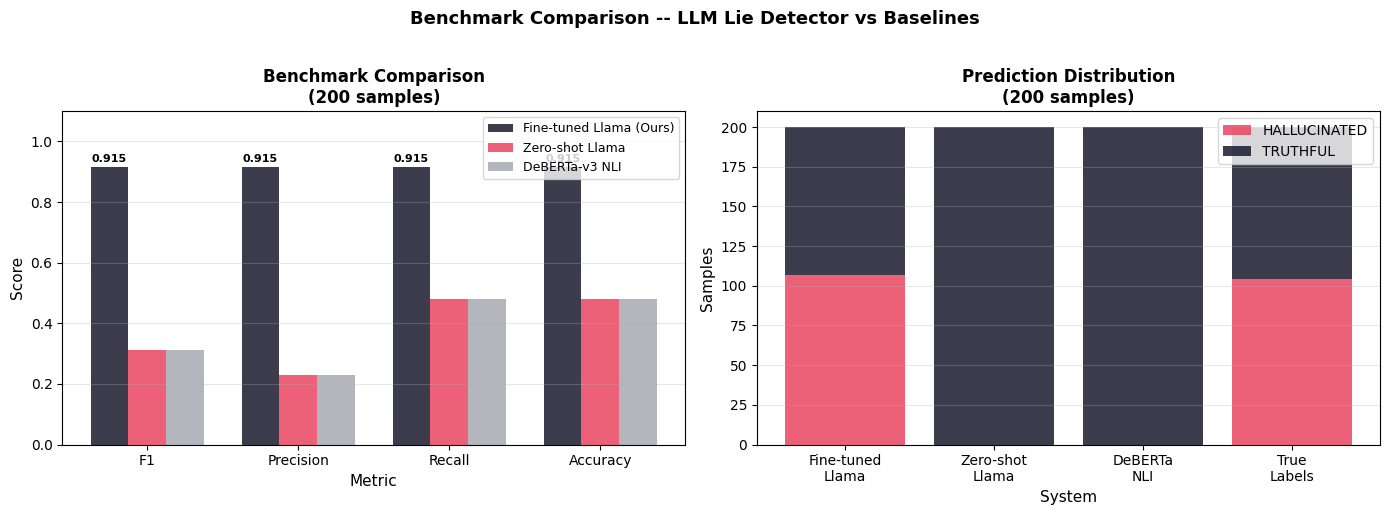

Saved to outputs/benchmark_comparison.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart comparison
metrics = ['F1', 'Precision', 'Recall', 'Accuracy']
ft_scores = [0.9149, 0.9153, 0.9150, 0.9150]
zs_scores = [0.3114, 0.2304, 0.4800, 0.4800]
db_scores = [0.3114, 0.2304, 0.4800, 0.4800]

x = np.arange(len(metrics))
width = 0.25

axes[0].bar(x - width, ft_scores, width, label='Fine-tuned Llama (Ours)',
            color='#1a1a2e', alpha=0.85)
axes[0].bar(x, zs_scores, width, label='Zero-shot Llama',
            color='#e94560', alpha=0.85)
axes[0].bar(x + width, db_scores, width, label='DeBERTa-v3 NLI',
            color='#a8a8b3', alpha=0.85)

for i, (ft, zs, db) in enumerate(zip(ft_scores, zs_scores, db_scores)):
    axes[0].text(i - width, ft + 0.01, f'{ft:.3f}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

axes[0].set_xlabel('Metric', fontsize=11)
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title('Benchmark Comparison\n(200 samples)',
                  fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1.1)
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Prediction distribution
systems = ['Fine-tuned\nLlama', 'Zero-shot\nLlama', 'DeBERTa\nNLI', 'True\nLabels']
hallucinated = [107, 0, 0, 104]
truthful = [93, 200, 200, 96]

x2 = np.arange(len(systems))
axes[1].bar(x2, hallucinated, label='HALLUCINATED', color='#e94560', alpha=0.85)
axes[1].bar(x2, truthful, bottom=hallucinated, label='TRUTHFUL',
            color='#1a1a2e', alpha=0.85)

axes[1].set_xlabel('System', fontsize=11)
axes[1].set_ylabel('Samples', fontsize=11)
axes[1].set_title('Prediction Distribution\n(200 samples)',
                  fontsize=12, fontweight='bold')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(systems)
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Benchmark Comparison -- LLM Lie Detector vs Baselines',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/benchmark_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/benchmark_comparison.png")